## Train Logistic Regression

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

def load_and_clean_data(json_path):
    print(f"Loading {json_path}...")
    df = pd.read_json(json_path, lines=True)
    
    initial_count = len(df)
    
    df['caption'] = df['caption'].replace(r'^\s*$', np.nan, regex=True)
    df_clean = df.dropna(subset=['caption']).copy()
    df_clean.drop(columns=['business_id'], inplace=True)
    
    final_count = len(df_clean)
    dropped_count = initial_count - final_count
    
    print(f"Total records: {initial_count}")
    print(f"Deleted: {dropped_count} ({dropped_count/initial_count:.1%})")
    print(f"Remaining: {final_count}")
    print("-" * 30)
    
    return df_clean

# Load original train and test data
train_path = '../data/train.json'
test_path = '../data/test.json'

df_train_orig = load_and_clean_data(train_path)
df_test_orig = load_and_clean_data(test_path)

# Combine both datasets
df_combined = pd.concat([df_train_orig, df_test_orig], ignore_index=True)

# Shuffle the combined dataset
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

# Split back into train and test with the same proportion as original
train_ratio = len(df_train_orig) / (len(df_train_orig) + len(df_test_orig))
df_train, df_test = train_test_split(
    df_combined, 
    train_size=train_ratio,
    stratify=df_combined['label'],
    random_state=42
)

print(f"Final train size: {len(df_train)} ({len(df_train)/len(df_combined):.1%})")
print(f"Final test size: {len(df_test)} ({len(df_test)/len(df_combined):.1%})")

# Save the cleaned and balanced datasets
df_train.to_csv('../data/train_cleaned.csv', index=False)
df_test.to_csv('../data/test_cleaned.csv', index=False)
print("Cleaned data saved to data/*_cleaned.csv")

print("\nClass distribution (train):")
print(df_train['label'].value_counts())

print("\nClass distribution (test):")
print(df_test['label'].value_counts())

Loading ../data/train.json...
Total records: 64274
Deleted: 33988 (52.9%)
Remaining: 30286
------------------------------
Loading ../data/test.json...
Total records: 9222
Deleted: 4793 (52.0%)
Remaining: 4429
------------------------------
Final train size: 30286 (87.2%)
Final test size: 4429 (12.8%)
Cleaned data saved to data/*_cleaned.csv

Class distribution (train):
label
food       9316
inside     7131
drink      6584
outside    6464
menu        791
Name: count, dtype: int64

Class distribution (test):
label
food       1362
inside     1043
drink       963
outside     945
menu        116
Name: count, dtype: int64


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

print("\nLogistic Regression text-only training started")

# Data preprocessing
X_train = df_train['caption']
y_train = df_train['label']

X_test = df_test['caption']
y_test = df_test['label']

# Vectorization -> classification
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)), 
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1))
])

# Model training
pipeline.fit(X_train, y_train)
print("\nLogistic Regression text-only training completed")

# Prediction
y_pred = pipeline.predict(X_test)



Logistic Regression text-only training started

Logistic Regression text-only training completed



Accuracy: 0.7489

Classification report:
              precision    recall  f1-score   support

       drink     0.7737    0.7456    0.7594       963
        food     0.7933    0.8510    0.8211      1362
      inside     0.7346    0.6635    0.6972      1043
        menu     0.4138    0.7241    0.5266       116
     outside     0.7419    0.7026    0.7217       945

    accuracy                         0.7489      4429
   macro avg     0.6915    0.7374    0.7052      4429
weighted avg     0.7543    0.7489    0.7496      4429


Confusion matrix (rows=true, cols=predicted):


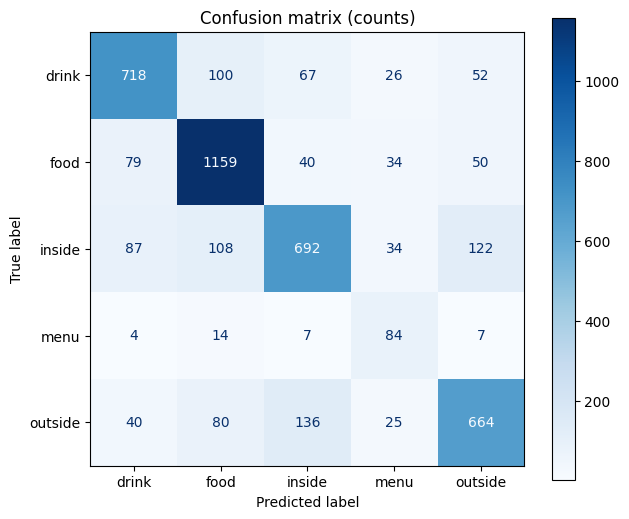


Normalized confusion matrix (by true class, i.e. recall per class):


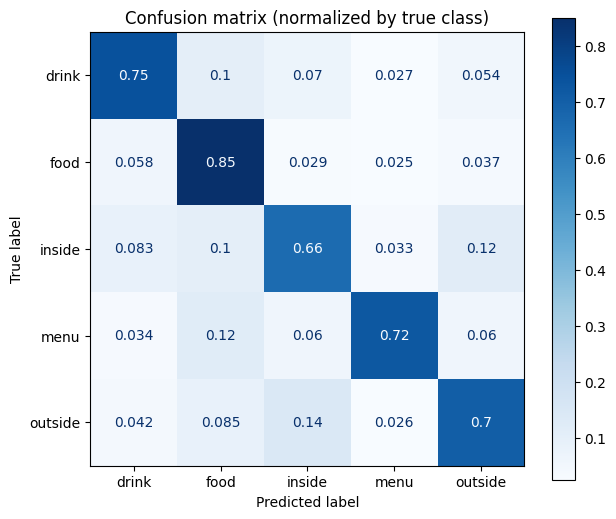

In [3]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


# Evaluation: basic
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix (numeric)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix (rows=true, cols=predicted):")

# Plot confusion matrix (raw counts)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=pipeline.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
ax.set_title("Confusion matrix (counts)")
plt.show()

# Normalized confusion matrix (by true label / recall per class)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
print("\nNormalized confusion matrix (by true class, i.e. recall per class):")

fig, ax = plt.subplots(figsize=(7, 6))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                   display_labels=pipeline.classes_)
disp_norm.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
ax.set_title("Confusion matrix (normalized by true class)")
plt.show()

In [4]:
print("\nPrediction examples:")
examples = X_test.sample(5)
preds = pipeline.predict(examples)
for text, label in zip(examples, preds):
    print(f"Text: {text[:50]}... -> Pred: {label}")


Prediction examples:
Text: Michael Angelo pizza and the Margherita pizza... -> Pred: food
Text: Padre Azul anejo, by the glass... -> Pred: drink
Text: Hibachi Shrimp & Steak... -> Pred: food
Text: Beautiful interior... -> Pred: inside
Text: Packed house... -> Pred: outside


## Fine-tuning BERT

In [5]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from datasets import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    DataCollatorWithPadding, 
    TrainingArguments, 
    Trainer
)
from peft import get_peft_model, LoraConfig, TaskType


MODEL_CHECKPOINT = "distilbert-base-uncased"
LR = 2e-4
BATCH_SIZE = 32
EPOCHS = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")

train_df = pd.read_csv('../data/train_cleaned.csv')
test_df = pd.read_csv('../data/test_cleaned.csv')

train_df['caption'] = train_df['caption'].fillna("").astype(str)
test_df['caption'] = test_df['caption'].fillna("").astype(str)

# Label Encoding
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['label'])
test_df['label'] = le.transform(test_df['label'])
num_labels = len(le.classes_)
print(f"Classes: {le.classes_}")

ds_train = Dataset.from_pandas(train_df[['caption', 'label']])
ds_test = Dataset.from_pandas(test_df[['caption', 'label']])

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_function(examples):
    return tokenizer(examples["caption"], truncation=True, max_length=128)

tokenized_train = ds_train.map(tokenize_function, batched=True)
tokenized_test = ds_test.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

c:\Users\chess\miniconda3\envs\multimodal_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Classes: ['drink' 'food' 'inside' 'menu' 'outside']


Map: 100%|██████████| 4429/4429 [00:00<00:00, 54490.01 examples/s]


In [6]:
print("Loading model...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=num_labels
)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, # Sequence Classification
    inference_mode=False, 
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"] 
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters() 

model.to(DEVICE)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading model...
trainable params: 741,893 || all params: 67,699,210 || trainable%: 1.0959


PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): DistilBertForSequenceClassification(
      (distilbert): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): DistilBertSdpaAttention(
                (dropout): Dropout(p=0.1, inplace=False)
                (q_lin): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=76

In [7]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

training_args = TrainingArguments(
    output_dir="../data/bert-lora-checkpoints",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\nStart Fine-Tuning...")
trainer.train()

C:\Users\chess\AppData\Local\Temp\ipykernel_26544\1105591435.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



Start Fine-Tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.809600,0.684767,0.745992
2,0.659800,0.663779,0.758185
3,0.612700,0.648207,0.769022
4,0.592800,0.645904,0.771054


TrainOutput(global_step=3788, training_loss=0.651660141748511, metrics={'train_runtime': 125.1028, 'train_samples_per_second': 968.356, 'train_steps_per_second': 30.279, 'total_flos': 970950610482552.0, 'train_loss': 0.651660141748511, 'epoch': 4.0})

In [8]:
print("\nLogit generation for ansamble...")

def get_predictions(dataset):
    preds_output = trainer.predict(dataset)
    logits = preds_output.predictions
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
    return probs

probs_train = get_predictions(tokenized_train)
probs_test = get_predictions(tokenized_test)

print(f"Shape of BERT probs: {probs_train.shape}")

np.save("../data/bert_finetuned_train.npy", probs_train)
np.save("../data/bert_finetuned_test.npy", probs_test)
print("Saved features to data/bert_finetuned_*.npy")


Logit generation for ansamble...


Shape of BERT probs: (30286, 5)
Saved features to data/bert_finetuned_*.npy



Accuracy: 0.7711

Raw result of Fine-Tuned BERT (without images):
              precision    recall  f1-score   support

       drink       0.76      0.75      0.76       963
        food       0.82      0.86      0.84      1362
      inside       0.72      0.73      0.72      1043
        menu       0.74      0.62      0.68       116
     outside       0.78      0.73      0.75       945

    accuracy                           0.77      4429
   macro avg       0.76      0.74      0.75      4429
weighted avg       0.77      0.77      0.77      4429


Confusion matrix (rows=true, cols=predicted):


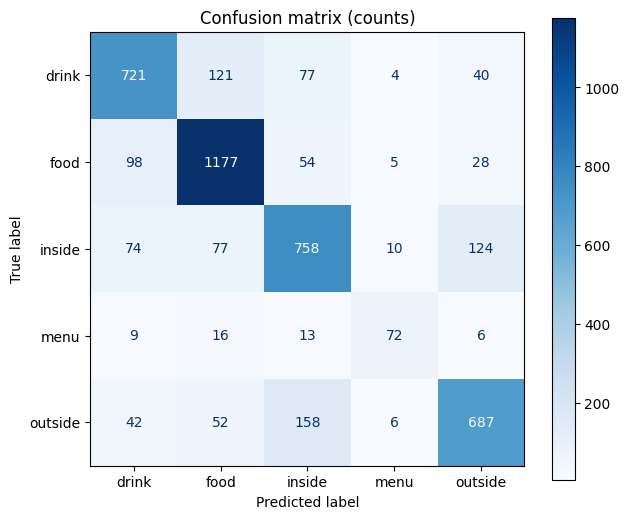


Normalized confusion matrix (by true class, i.e. recall per class):


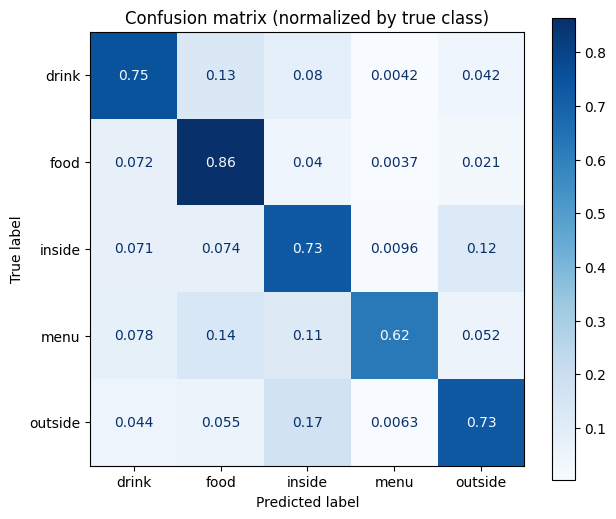

In [9]:
# Quick check
y_pred_bert = np.argmax(probs_test, axis=1)
y_test_bert = test_df['label']

accuracy = accuracy_score(y_test_bert, y_pred_bert)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nRaw result of Fine-Tuned BERT (without images):")
print(classification_report(y_test_bert, y_pred_bert, target_names=le.classes_))

# Confusion matrix (numeric)
cm = confusion_matrix(y_test_bert, y_pred_bert)
print("\nConfusion matrix (rows=true, cols=predicted):")

# Plot confusion matrix (raw counts)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=pipeline.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
ax.set_title("Confusion matrix (counts)")
plt.show()

# Normalized confusion matrix (by true label / recall per class)
cm_norm = confusion_matrix(y_test_bert, y_pred_bert, normalize='true')
print("\nNormalized confusion matrix (by true class, i.e. recall per class):")

fig, ax = plt.subplots(figsize=(7, 6))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                   display_labels=pipeline.classes_)
disp_norm.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
ax.set_title("Confusion matrix (normalized by true class)")
plt.show()